In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:

df = pd.read_csv("schoolr.csv")

print(df.head())

print(df.shape)

print(df.columns)

print(df.info())

   Serial Number Roll Number    Name Father Name  Admission Year Category  \
0       11223001       R1000   Kamal     Prakash          2006.0       BC   
1       11223002       R1001   Vikas      Rajesh          2008.0       BC   
2       11223003       R1002   Suman      Rajesh          2006.0     GNRL   
3       11223004       R1003  Anjali      Naresh          2003.0       BC   
4       11223005       R1004   Mohit      Dinesh          2001.0       SC   

  Gender Grade       City Standard  Hindi Marks  English Marks  Science Marks  \
0      F     C  Faridabad     12th         56.0           19.0           58.0   
1      M     A    Panipat     11th         75.0            0.0           20.0   
2      M     D  Faridabad      7th         42.0           48.0           46.0   
3      F     C     Rohtak     12th         26.0           12.0           51.0   
4      F     A    Gurgaon      9th         70.0           51.0           27.0   

   Maths Marks  Drawing Marks  Total Marks  Percen

In [3]:
print(df.isnull().sum())

Serial Number     0
Roll Number       0
Name              8
Father Name       5
Admission Year    3
Category          9
Gender            6
Grade             6
City              9
Standard          6
Hindi Marks       8
English Marks     3
Science Marks     4
Maths Marks       5
Drawing Marks     6
Total Marks       7
Percentage        5
dtype: int64


In [4]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [5]:
print(df.duplicated().sum())

df = df.drop_duplicates()

0


In [6]:
print(df.describe())

       Serial Number  Admission Year  Hindi Marks  English Marks  \
count   9.000000e+02      900.000000   900.000000     900.000000   
mean    1.122345e+07     2004.657778    49.833333      49.404444   
std     2.599519e+02        2.880373    29.102041      28.967144   
min     1.122300e+07     2000.000000     0.000000       0.000000   
25%     1.122323e+07     2002.000000    25.000000      26.000000   
50%     1.122345e+07     2005.000000    50.000000      48.000000   
75%     1.122368e+07     2007.000000    75.000000      74.000000   
max     1.122390e+07     2009.000000   100.000000     100.000000   

       Science Marks  Maths Marks  Drawing Marks  Total Marks  Percentage  
count     900.000000   900.000000     900.000000   900.000000  900.000000  
mean       48.323333    50.172222      50.327778   248.277778   49.687333  
std        28.931412    28.302323      30.174765    65.960741   13.209993  
min         0.000000     0.000000       0.000000    50.000000   10.000000  
25%    

In [7]:
df.to_csv("cleaned_school_data.csv", index=False)

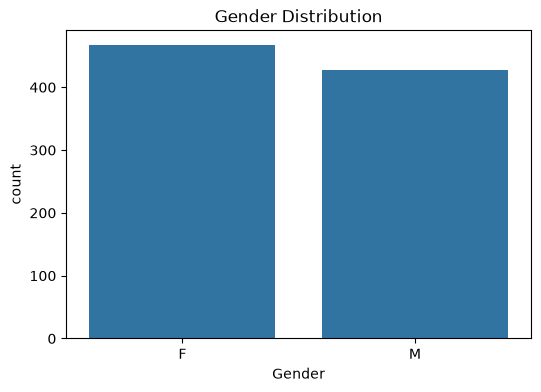

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df  )

plt.title("Gender Distribution")

plt.show()

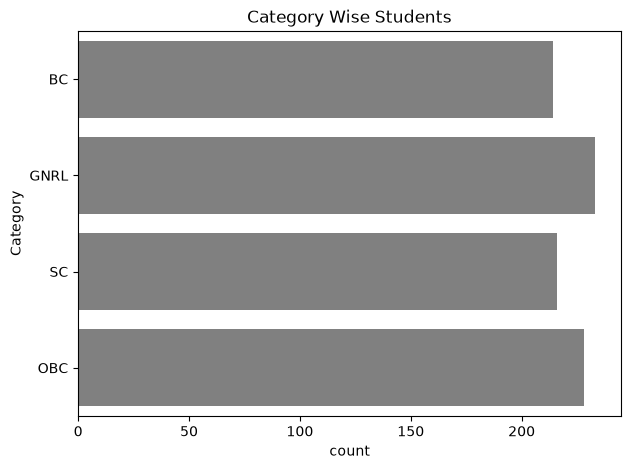

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(y='Category', data=df , color='grey')

plt.title("Category Wise Students")

plt.show()

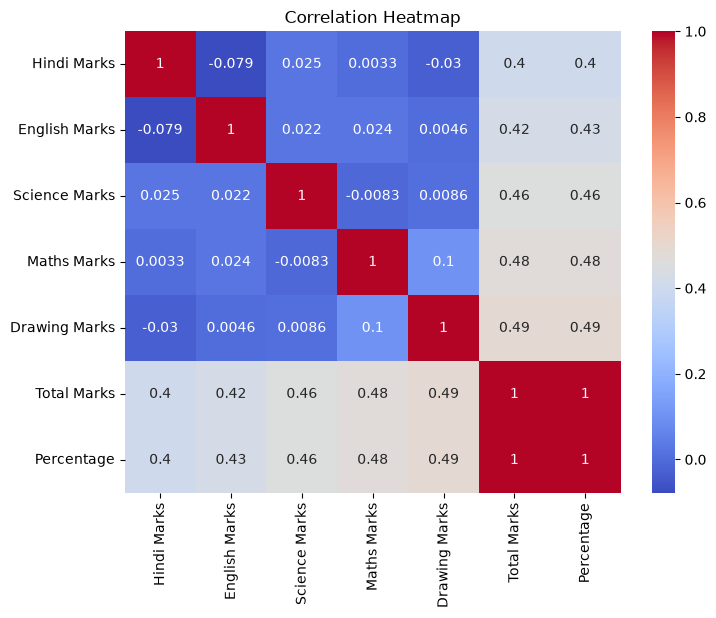

In [10]:
marks = [
'Hindi Marks',
'English Marks',
'Science Marks',
'Maths Marks',
'Drawing Marks',
'Total Marks',
'Percentage'
]

plt.figure(figsize=(8,6))

sns.heatmap(df[marks].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [11]:
print(df.loc[df['Percentage'].idxmax()])

Serial Number     11223429
Roll Number          R1428
Name                   NaN
Father Name         Naresh
Admission Year      2007.0
Category                BC
Gender                   M
Grade                    C
City                Ambala
Standard               6th
Hindi Marks          100.0
English Marks         97.0
Science Marks         92.0
Maths Marks           97.0
Drawing Marks         89.0
Total Marks          475.0
Percentage            95.0
Name: 428, dtype: object


In [12]:
print(df['Percentage'].mean())

49.68733333333334


In [13]:
pass_students = (df['Percentage'] >= 33).sum()

fail_students = (df['Percentage'] < 33).sum()

print("Pass :", pass_students)

print("Fail :", fail_students)

Pass : 805
Fail : 95


In [14]:
print(df['City'].value_counts().head())

City
Faridabad    104
Ambala       101
Rohtak        99
Hisar         98
Jhajjar       90
Name: count, dtype: int64


In [16]:
df.to_csv("cleaned_school_data.csv", index=False)
df.Gender.count()

np.int64(894)